# Least squares GANs

Original paper: [Least Squares Generative Adversarial Networks](https://arxiv.org/abs/1611.04076)


In [1]:
import os
import torch
import torchvision
import torchvision.transforms as T
from torch import nn
import matplotlib.pyplot as plt
from typing import Tuple
import numpy as np

In [2]:
batch_size = 128
transform = T.Compose([
    T.ToTensor(), T.Normalize((0.5,),(0.5,))
])
data = torchvision.datasets.MNIST(
    root="./mnist", train=True, download=True, transform=transform)
print(f"Dataset size: {len(data)}")

Dataset size: 60000


In [3]:
dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)

In [4]:
def plot_images(images: torch.Tensor, nrow: int = 8,
                figsize: Tuple[float] = (8,6), save_name: str = None,
                show: bool = True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(T.ToPILImage()(torchvision.utils.make_grid(images, nrow=nrow)))
    ax.axis("off")
    if save_name: fig.savefig(save_name, bbox_inches="tight", pad_inches=1)
    if show: plt.show()
    plt.close()

torch.Size([128, 1, 28, 28])


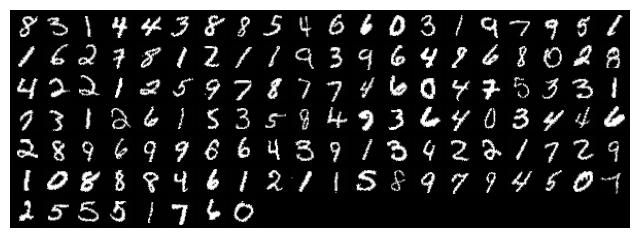

In [5]:
for batch in dataloader:
    x, y = batch
    print(x.shape)
    plot_images(x, nrow=20)
    
    break

In [6]:
class VGGGenerator(nn.Sequential):
    def __init__(self, latent_dim: int = 1024, output_channels: int = 3):
        super(VGGGenerator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features=latent_dim, out_features=7*7*256),
            nn.ReLU(), nn.BatchNorm1d(7*7*256)
        )
        self.convs = nn.Sequential(
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 14, 14)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 14, 14)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 28, 28)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 28, 28)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=128, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(), # output shape: (256, 56, 56)
            nn.ConvTranspose2d(kernel_size=3, in_channels=128, out_channels=64, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), # output shape: (256, 112, 112)
            nn.ConvTranspose2d(kernel_size=3, in_channels=64, out_channels=output_channels, stride=1, padding=1), # output shape: (256, 112, 112)
            nn.Tanh()
        )

    def forward(self, x):
        out = self.fc(x)
        out = out.view(out.size(0),256,7,7)
        out = self.convs(out)
        return out

In [7]:
generator = VGGGenerator()
ex_input = torch.normal(0., 1., (16, 1024))
ex_output = generator(ex_input)
print("Input shape:", ex_input.shape)
print("Output shape:", ex_output.shape)

Input shape: torch.Size([16, 1024])
Output shape: torch.Size([16, 3, 112, 112])


In [8]:
class VGGMnistGenerator(nn.Sequential):
    def __init__(self, latent_dim: int = 1024, output_channels: int = 3):
        super(VGGMnistGenerator, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(in_features=latent_dim, out_features=1*1*256),
            nn.ReLU(), nn.BatchNorm1d(1*1*256)
        )
        self.convs = nn.Sequential(
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 3, 3)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 3, 3)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 7, 7)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=256, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(), # output shape: (256, 7, 7)
            nn.ConvTranspose2d(kernel_size=3, in_channels=256, out_channels=128, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(), # output shape: (256, 14, 14)
            nn.ConvTranspose2d(kernel_size=3, in_channels=128, out_channels=64, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), # output shape: (256, 25, 28)
            nn.ConvTranspose2d(kernel_size=3, in_channels=64, out_channels=output_channels, stride=1, padding=1), # output shape: (256, 112, 112)
            nn.Tanh()
        )

    def forward(self, x):
        out = self.fc(x)
        out = out.view(out.size(0),256,1,1)
        out = self.convs(out)
        return out

In [9]:
generator = VGGMnistGenerator()
ex_input = torch.normal(0., 1., (16, 1024))
ex_output = generator(ex_input)
print("Input shape:", ex_input.shape)
print("Output shape:", ex_output.shape)

Input shape: torch.Size([16, 1024])
Output shape: torch.Size([16, 3, 28, 28])


In [10]:
class VGGDiscriminator(nn.Module):
    def __init__(self, input_channels: int = 3, alpha: float = 0.2):
        super(VGGDiscriminator, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(kernel_size=5, in_channels=input_channels, out_channels=64, stride=2, padding=2),
            nn.LeakyReLU(alpha), # output shape: (64, 56, 56)
            nn.Conv2d(kernel_size=5, in_channels=64, out_channels=128, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(alpha), # output shape: (128, 28, 28)
            nn.Conv2d(kernel_size=5, in_channels=128, out_channels=256, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(alpha), # output shape: (256, 14, 14)
            nn.Conv2d(kernel_size=5, in_channels=256, out_channels=512, stride=2, padding=2),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(alpha), # output shape: (512, 7, 7)
        )
        self.fc = nn.Linear(in_features=512*7*7, out_features=1)
    
    def forward(self, x):
        out = self.convs(x)
        out = out.view(out.size(0), 512*7*7)
        out = self.fc(out)
        return out

In [11]:
discriminator = VGGDiscriminator()
ex_input = torch.normal(0., 1., (16, 3, 112, 112))
ex_output = discriminator(ex_input)
print("Input shape:", ex_input.shape)
print("Output shape:", ex_output.shape)

Input shape: torch.Size([16, 3, 112, 112])
Output shape: torch.Size([16, 1])


In [12]:
class VGGMnistDiscriminator(nn.Module):
    def __init__(self, input_channels: int = 3, alpha: float = 0.2):
        super(VGGMnistDiscriminator, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(kernel_size=5, in_channels=input_channels, out_channels=64, stride=2, padding=2),
            nn.LeakyReLU(alpha), # output shape: (64, 14, 14)
            nn.Conv2d(kernel_size=5, in_channels=64, out_channels=128, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(alpha), # output shape: (128, 7, 7)
            nn.Conv2d(kernel_size=5, in_channels=128, out_channels=256, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(alpha), # output shape: (256, 4, 4)
            nn.Conv2d(kernel_size=5, in_channels=256, out_channels=512, stride=2, padding=2),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(alpha), # output shape: (512, 2, 2)
        )
        self.fc = nn.Linear(in_features=512*2*2, out_features=1)
    
    def forward(self, x):
        out = self.convs(x)
        out = out.view(out.size(0), 512*2*2)
        out = self.fc(out)
        return out

In [13]:
discriminator = VGGMnistDiscriminator()
ex_input = torch.normal(0., 1., (16, 3, 28, 28))
ex_output = discriminator(ex_input)
print("Input shape:", ex_input.shape)
print("Output shape:", ex_output.shape)

Input shape: torch.Size([16, 3, 28, 28])
Output shape: torch.Size([16, 1])


In [14]:
def update_discriminator(x, z, G, D, trainer_D, a, b):
    criterion = nn.MSELoss()
    trainer_D.zero_grad()
    bs = x.size(0)
    real_labels = torch.zeros((bs,), device=x.device).fill_(b)
    fake_labels = torch.zeros((bs,), device=x.device).fill_(a)
    fake_x = G(z)
    fake_y = D(fake_x.detach())
    real_y = D(x)
    loss_D = 0.5 * criterion(real_y, real_labels.reshape(real_y.shape)) + 0.5 * criterion(fake_y, fake_labels.reshape(fake_y.shape))
    loss_D.backward()
    trainer_D.step()
    return loss_D.item()

def update_generator(z, G, D, trainer_G, c):
    criterion = nn.MSELoss()
    trainer_G.zero_grad()
    bs = z.size(0)
    real_labels = torch.zeros((bs,), device=z.device).fill_(c)
    fake_y = D(G(z))
    loss_G = 0.5 * criterion(fake_y, real_labels.reshape(fake_y.shape))
    loss_G.backward()
    trainer_G.step()
    return loss_G.item()

In [15]:
def init_weights(w):
    if isinstance(w, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d)):
        torch.nn.init.normal_(w.weight.data, 0., 0.02)
        if w.bias is not None:
            torch.nn.init.constant_(w.bias.data, 0.0)
    elif isinstance(w, (nn.BatchNorm2d, nn.BatchNorm1d)):
        torch.nn.init.normal_(w.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(w.bias.data, 0.0)

def train_least_gan(D, G, device, lr_D, lr_G, a, b, c, num_epochs, latent_dim, fixed_noise, dataloader, plot_each=10):
    print(f"Device: {device}")
    D = D.to(device)
    G = G.to(device)
    fixed_noise = fixed_noise.to(device)

    # for w in D.parameters(): torch.nn.init.normal_(w, 0., 0.02)
    # for w in G.parameters(): torch.nn.init.normal_(w, 0., 0.02)

    D.apply(init_weights)
    G.apply(init_weights)

    trainer_D = torch.optim.Adam(D.parameters(), lr_D, betas=(0.5, 0.999))
    trainer_G = torch.optim.Adam(G.parameters(), lr_G, betas=(0.5, 0.999))

    metrics = []
    os.makedirs("visualizations", exist_ok=True)
    
    for epoch in range(num_epochs):
        epoch_loss_D = 0.
        epoch_loss_G = 0.
        num_instances = 0.

        for batch in dataloader:
            x, _ = batch
            bs = x.size(0)
            x = x.to(device)
            z = torch.normal(0., 1., (bs, latent_dim), device=device)
            loss_D = update_discriminator(x=x, z=z, G=G, D=D, a=a, b=b, trainer_D=trainer_D)
            loss_G = update_generator(z=z, G=G, D=D, c=c, trainer_G=trainer_G)
            epoch_loss_D += loss_D * bs
            epoch_loss_G += loss_G * bs
            num_instances += bs
        epoch_loss_D /= num_instances
        epoch_loss_G /= num_instances
        metrics.append([epoch_loss_D, epoch_loss_G])
        print(f"[Epoch {epoch}/{num_epochs}] loss_D: {epoch_loss_D:.4f}, loss_G: {epoch_loss_G:.4f}")
    
        gen_imgs = G(fixed_noise)
        plot_images(gen_imgs, nrow=5, figsize=(19.2,10.8), save_name=f"visualizations/{epoch:2d}.png", show=epoch%plot_each==0)

    metrics = np.array(metrics)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(metrics[:, 0], label="loss_D")
    ax.plot(metrics[:, 1], label="loss_G")
    ax.legend()
    fig.savefig("losses.png")
    plt.show()
    plt.close()

    

Device: cuda
[Epoch 0/50] loss_D: 0.4369, loss_G: 1.2202


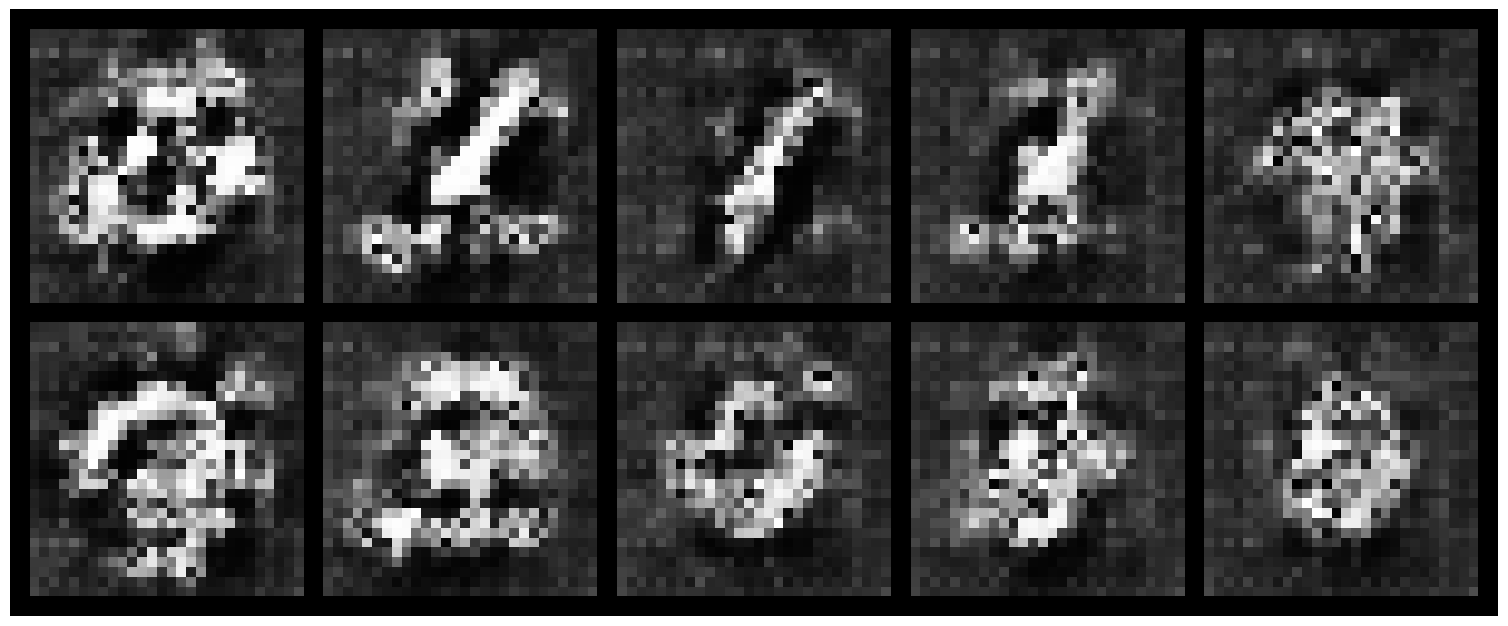

[Epoch 1/50] loss_D: 0.4435, loss_G: 0.5425
[Epoch 2/50] loss_D: 0.5354, loss_G: 0.3682
[Epoch 3/50] loss_D: 0.5743, loss_G: 0.3468
[Epoch 4/50] loss_D: 0.5867, loss_G: 0.3186
[Epoch 5/50] loss_D: 0.6151, loss_G: 0.3028
[Epoch 6/50] loss_D: 0.6120, loss_G: 0.3117
[Epoch 7/50] loss_D: 0.5944, loss_G: 0.3025
[Epoch 8/50] loss_D: 0.5863, loss_G: 0.3308
[Epoch 9/50] loss_D: 0.5691, loss_G: 0.3224
[Epoch 10/50] loss_D: 0.5607, loss_G: 0.3423


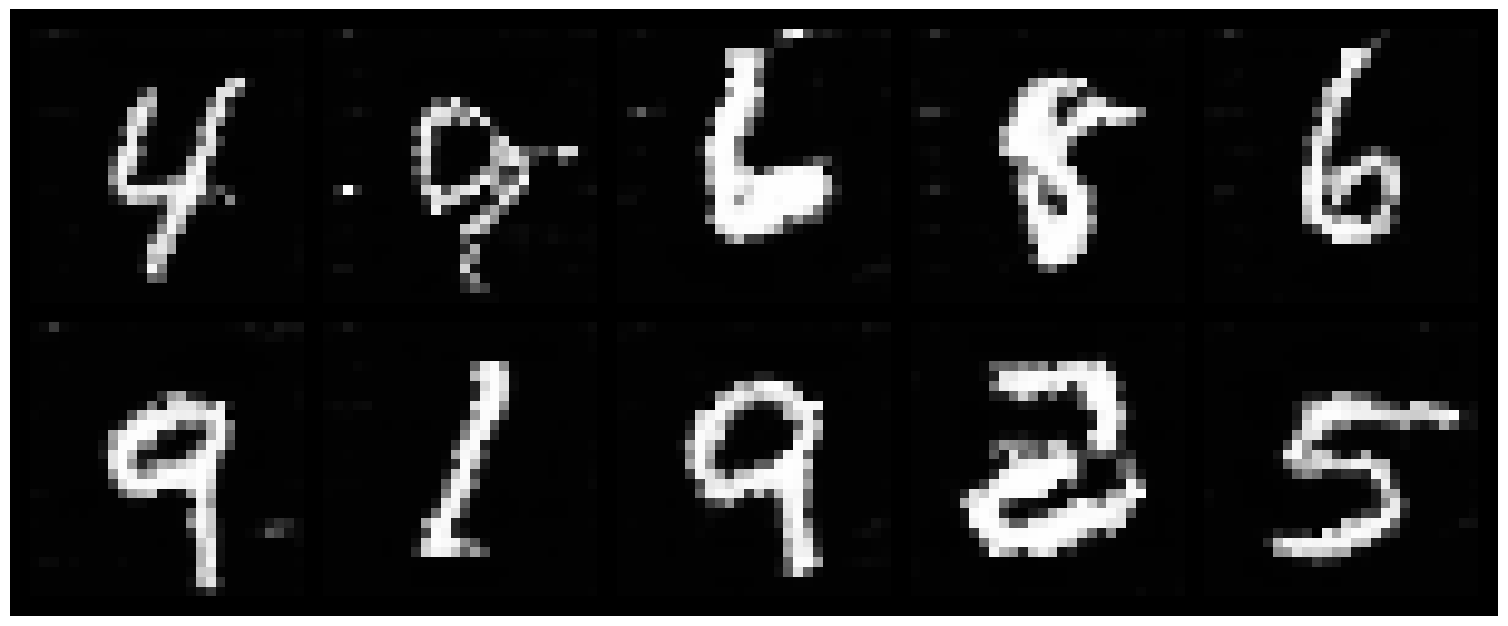

[Epoch 11/50] loss_D: 0.5383, loss_G: 0.3531
[Epoch 12/50] loss_D: 0.5203, loss_G: 0.3744
[Epoch 13/50] loss_D: 0.4502, loss_G: 0.4200
[Epoch 14/50] loss_D: 0.4855, loss_G: 0.4007
[Epoch 15/50] loss_D: 0.4347, loss_G: 0.4338
[Epoch 16/50] loss_D: 0.4292, loss_G: 0.4346
[Epoch 17/50] loss_D: 0.4007, loss_G: 0.4424
[Epoch 18/50] loss_D: 0.3523, loss_G: 0.4868
[Epoch 19/50] loss_D: 0.3596, loss_G: 0.4942
[Epoch 20/50] loss_D: 0.3507, loss_G: 0.4922


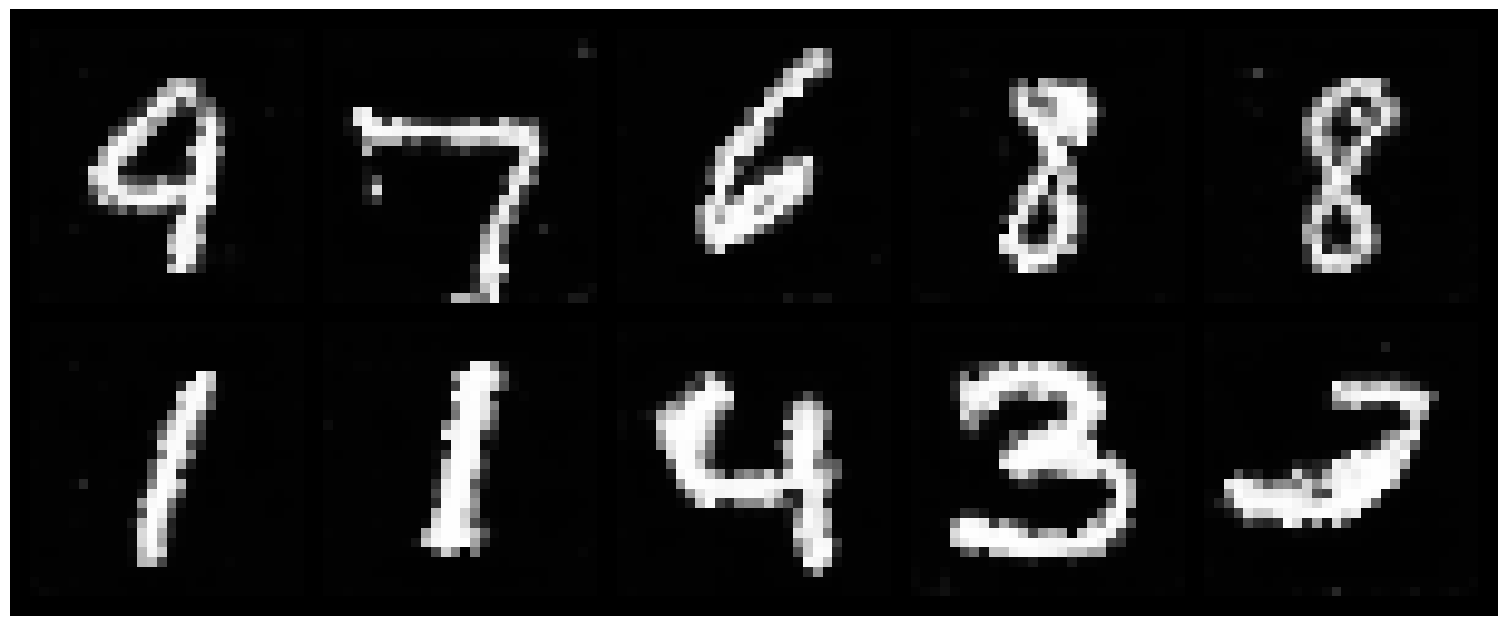

[Epoch 21/50] loss_D: 0.3330, loss_G: 0.5127
[Epoch 22/50] loss_D: 0.3320, loss_G: 0.5285
[Epoch 23/50] loss_D: 0.3170, loss_G: 0.4979
[Epoch 24/50] loss_D: 0.3146, loss_G: 0.5304
[Epoch 25/50] loss_D: 0.2829, loss_G: 0.5428
[Epoch 26/50] loss_D: 0.2920, loss_G: 0.5333
[Epoch 27/50] loss_D: 0.2751, loss_G: 0.5572
[Epoch 28/50] loss_D: 0.2855, loss_G: 0.5591
[Epoch 29/50] loss_D: 0.2846, loss_G: 0.5494
[Epoch 30/50] loss_D: 0.2726, loss_G: 0.5430


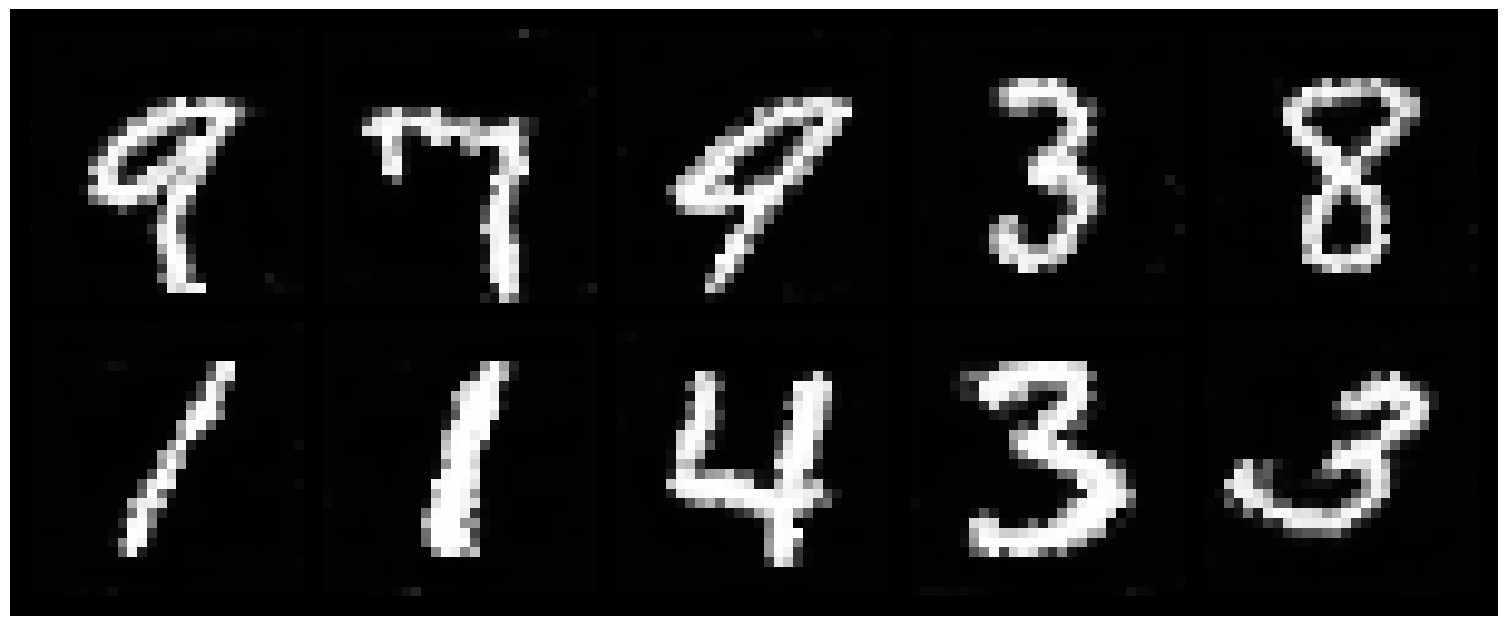

[Epoch 31/50] loss_D: 0.2627, loss_G: 0.5520
[Epoch 32/50] loss_D: 0.2653, loss_G: 0.5637
[Epoch 33/50] loss_D: 0.2527, loss_G: 0.5718
[Epoch 34/50] loss_D: 0.2521, loss_G: 0.5727
[Epoch 35/50] loss_D: 0.2489, loss_G: 0.5857
[Epoch 36/50] loss_D: 0.2465, loss_G: 0.5832
[Epoch 37/50] loss_D: 0.2278, loss_G: 0.5731
[Epoch 38/50] loss_D: 0.2374, loss_G: 0.5867
[Epoch 39/50] loss_D: 0.2339, loss_G: 0.5825
[Epoch 40/50] loss_D: 0.2271, loss_G: 0.5925


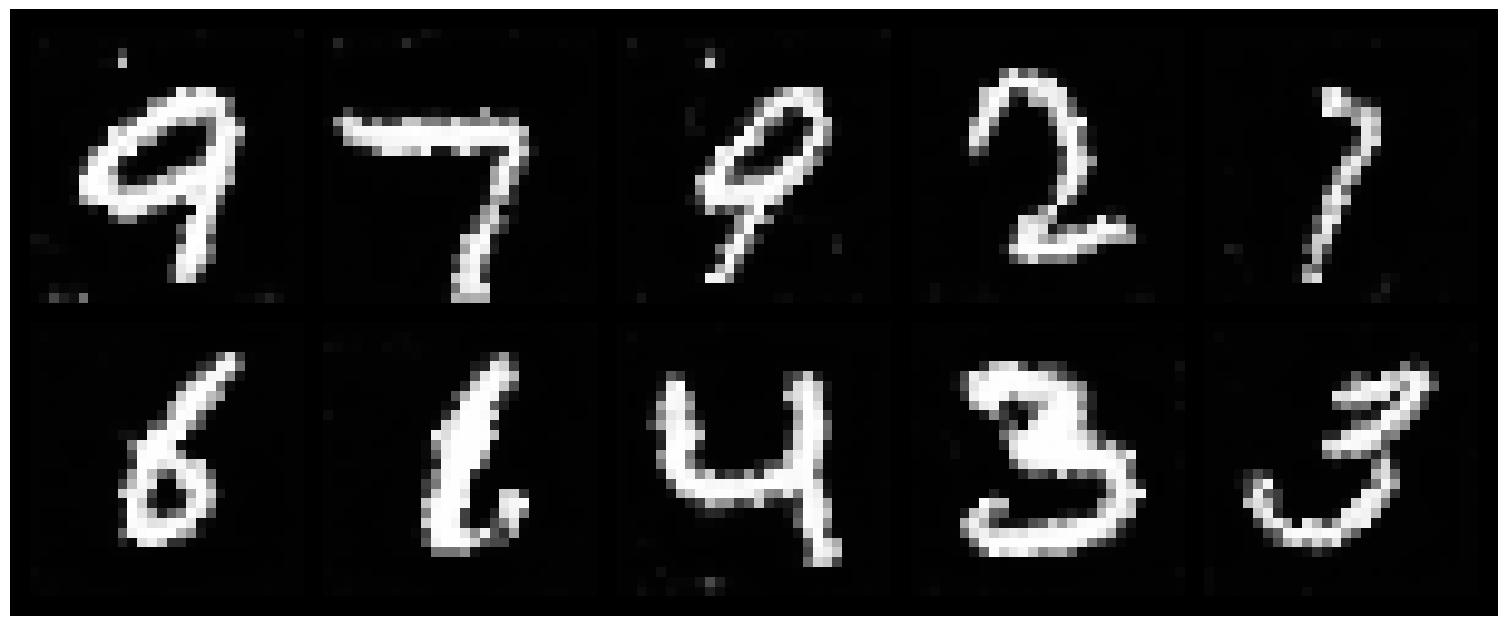

[Epoch 41/50] loss_D: 0.2357, loss_G: 0.5946
[Epoch 42/50] loss_D: 0.2265, loss_G: 0.5819
[Epoch 43/50] loss_D: 0.2099, loss_G: 0.5814
[Epoch 44/50] loss_D: 0.2193, loss_G: 0.5878
[Epoch 45/50] loss_D: 0.2157, loss_G: 0.5954
[Epoch 46/50] loss_D: 0.2180, loss_G: 0.5973
[Epoch 47/50] loss_D: 0.2113, loss_G: 0.5883
[Epoch 48/50] loss_D: 0.1987, loss_G: 0.5946
[Epoch 49/50] loss_D: 0.2095, loss_G: 0.5864


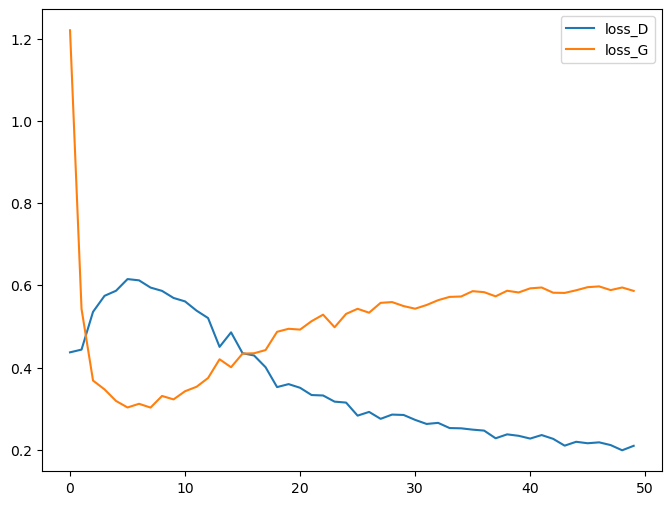

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 50
lr_D = 0.0002
lr_G = 0.0002
latent_dim = 1024
fixed_noise = torch.normal(0., 1., (10, latent_dim))

a = -1.
b = 1.
c = 0.

generator = VGGMnistGenerator(latent_dim=latent_dim, output_channels=1)
discriminator = VGGMnistDiscriminator(input_channels=1, alpha=0.2)
train_least_gan(D=discriminator, G=generator, device=device,
                lr_D=lr_D, lr_G=lr_G, a=a, b=b, c=c,
                num_epochs=num_epochs, latent_dim=latent_dim,
                dataloader=dataloader,
                fixed_noise=fixed_noise)



Device: cuda
[Epoch 0/50] loss_D: 0.2091, loss_G: 0.8919


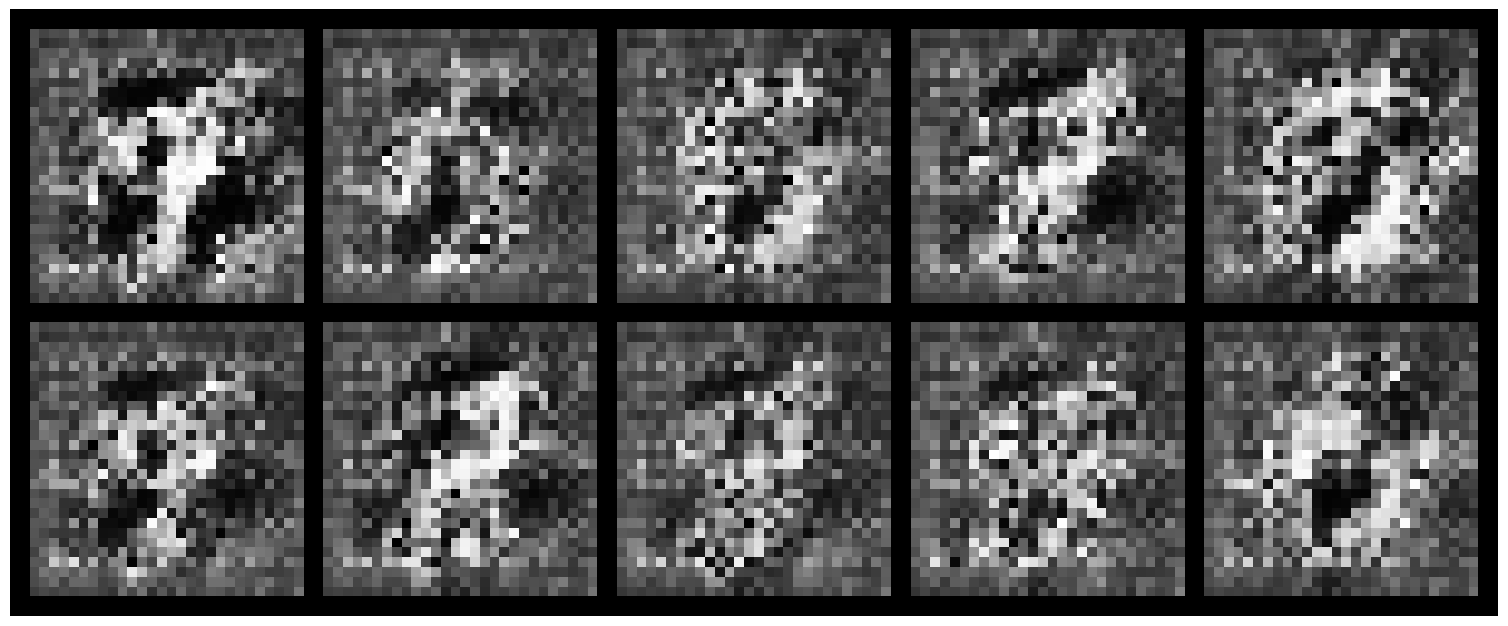

[Epoch 1/50] loss_D: 0.1202, loss_G: 0.5936
[Epoch 2/50] loss_D: 0.1301, loss_G: 0.5139
[Epoch 3/50] loss_D: 0.1301, loss_G: 0.4868
[Epoch 4/50] loss_D: 0.1305, loss_G: 0.4862
[Epoch 5/50] loss_D: 0.1208, loss_G: 0.5037
[Epoch 6/50] loss_D: 0.1061, loss_G: 0.4978
[Epoch 7/50] loss_D: 0.1278, loss_G: 0.4608
[Epoch 8/50] loss_D: 0.1234, loss_G: 0.4650
[Epoch 9/50] loss_D: 0.1095, loss_G: 0.4885
[Epoch 10/50] loss_D: 0.1064, loss_G: 0.4941


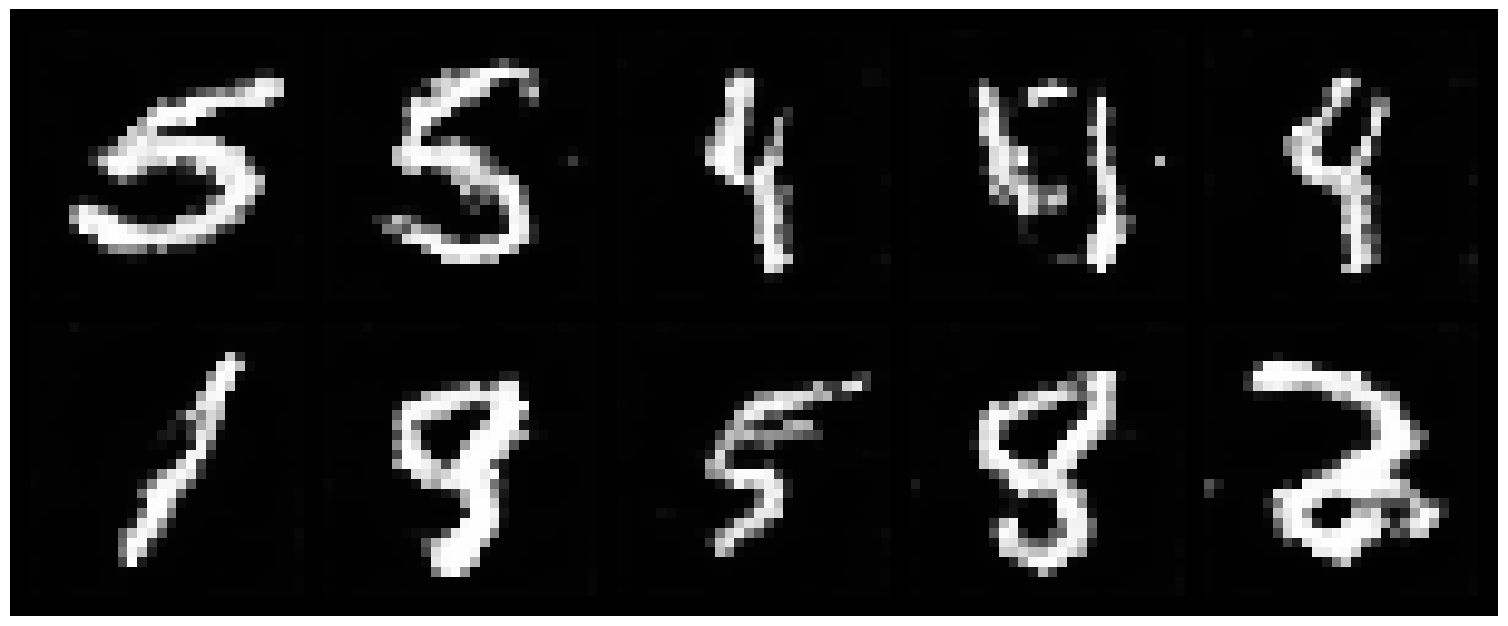

[Epoch 11/50] loss_D: 0.1009, loss_G: 0.4967
[Epoch 12/50] loss_D: 0.1107, loss_G: 0.4958
[Epoch 13/50] loss_D: 0.1203, loss_G: 0.4759
[Epoch 14/50] loss_D: 0.1185, loss_G: 0.4717
[Epoch 15/50] loss_D: 0.1063, loss_G: 0.4919
[Epoch 16/50] loss_D: 0.1052, loss_G: 0.4840
[Epoch 17/50] loss_D: 0.0902, loss_G: 0.4993
[Epoch 18/50] loss_D: 0.1005, loss_G: 0.4892
[Epoch 19/50] loss_D: 0.0894, loss_G: 0.4977
[Epoch 20/50] loss_D: 0.0936, loss_G: 0.4989


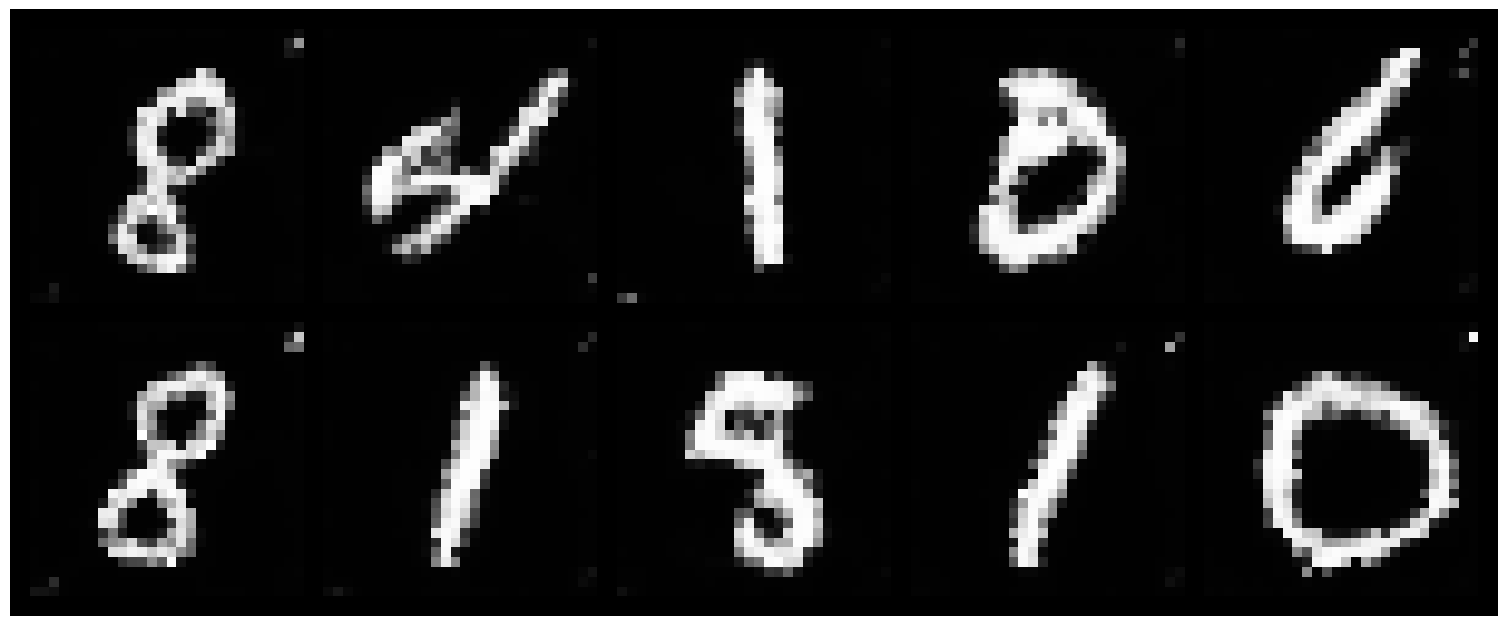

[Epoch 21/50] loss_D: 0.0949, loss_G: 0.4986
[Epoch 22/50] loss_D: 0.0961, loss_G: 0.4988
[Epoch 23/50] loss_D: 0.0976, loss_G: 0.4973
[Epoch 24/50] loss_D: 0.0937, loss_G: 0.5045
[Epoch 25/50] loss_D: 0.0928, loss_G: 0.5023
[Epoch 26/50] loss_D: 0.0929, loss_G: 0.4954
[Epoch 27/50] loss_D: 0.0901, loss_G: 0.5006
[Epoch 28/50] loss_D: 0.0952, loss_G: 0.4854
[Epoch 29/50] loss_D: 0.0850, loss_G: 0.5016
[Epoch 30/50] loss_D: 0.0800, loss_G: 0.5133


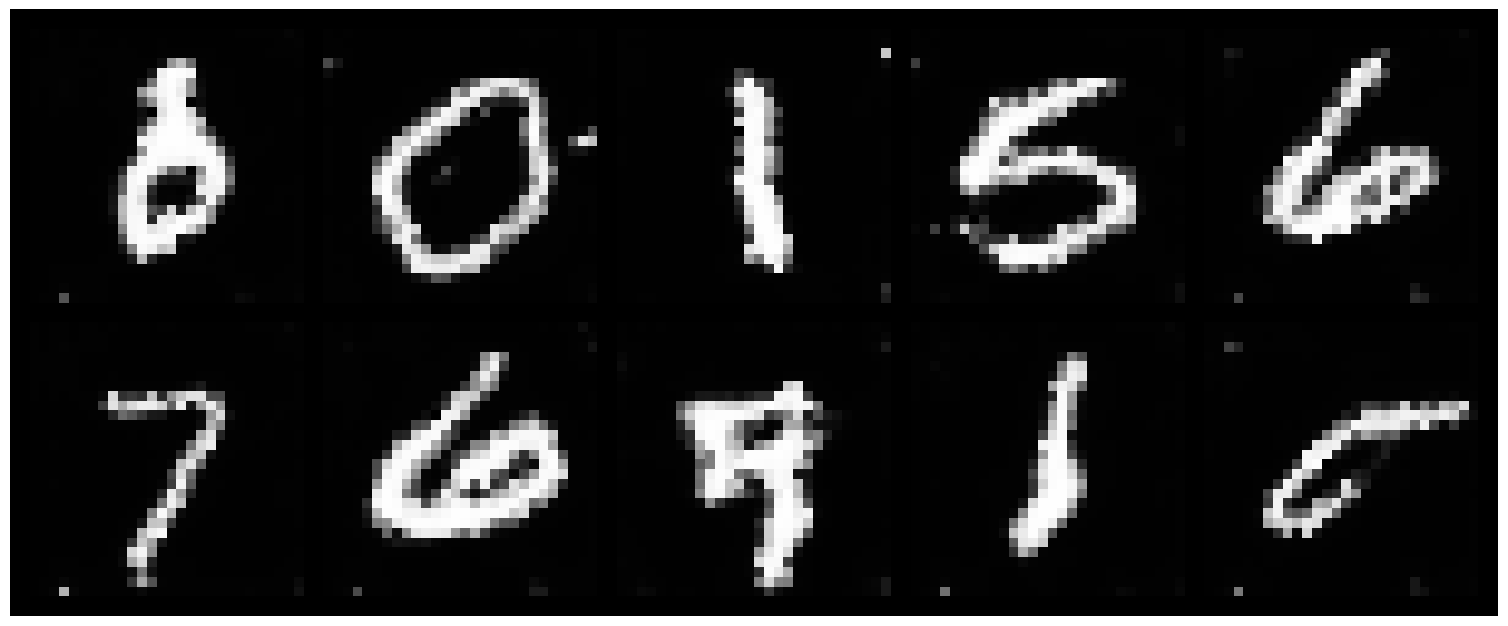

[Epoch 31/50] loss_D: 0.0852, loss_G: 0.5053
[Epoch 32/50] loss_D: 0.0904, loss_G: 0.5006
[Epoch 33/50] loss_D: 0.0803, loss_G: 0.5095
[Epoch 34/50] loss_D: 0.0862, loss_G: 0.5033
[Epoch 35/50] loss_D: 0.0850, loss_G: 0.5073
[Epoch 36/50] loss_D: 0.0812, loss_G: 0.5228
[Epoch 37/50] loss_D: 0.0840, loss_G: 0.5033
[Epoch 38/50] loss_D: 0.0920, loss_G: 0.5008
[Epoch 39/50] loss_D: 0.0868, loss_G: 0.4999
[Epoch 40/50] loss_D: 0.0866, loss_G: 0.4984


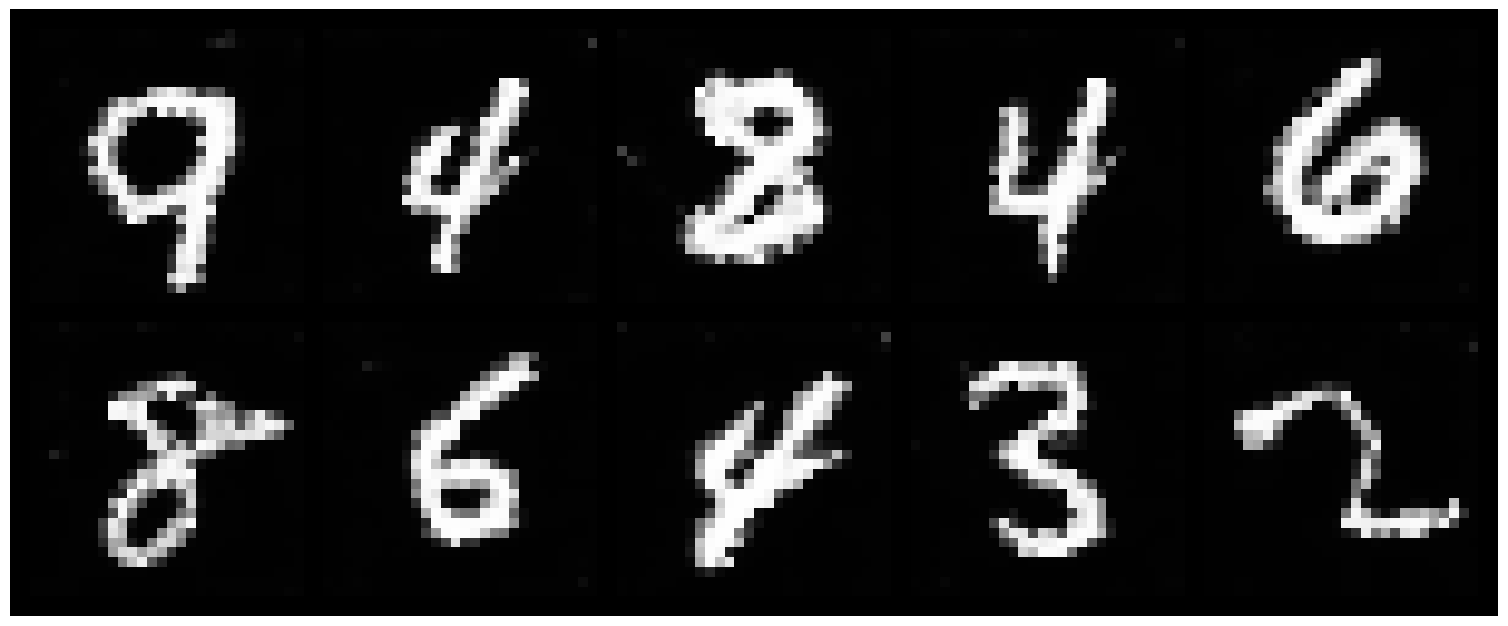

[Epoch 41/50] loss_D: 0.0808, loss_G: 0.5060
[Epoch 42/50] loss_D: 0.0836, loss_G: 0.5165
[Epoch 43/50] loss_D: 0.0820, loss_G: 0.5041
[Epoch 44/50] loss_D: 0.0801, loss_G: 0.5105
[Epoch 45/50] loss_D: 0.0782, loss_G: 0.5130
[Epoch 46/50] loss_D: 0.0765, loss_G: 0.5115
[Epoch 47/50] loss_D: 0.0771, loss_G: 0.5166
[Epoch 48/50] loss_D: 0.0785, loss_G: 0.5116
[Epoch 49/50] loss_D: 0.0808, loss_G: 0.5070


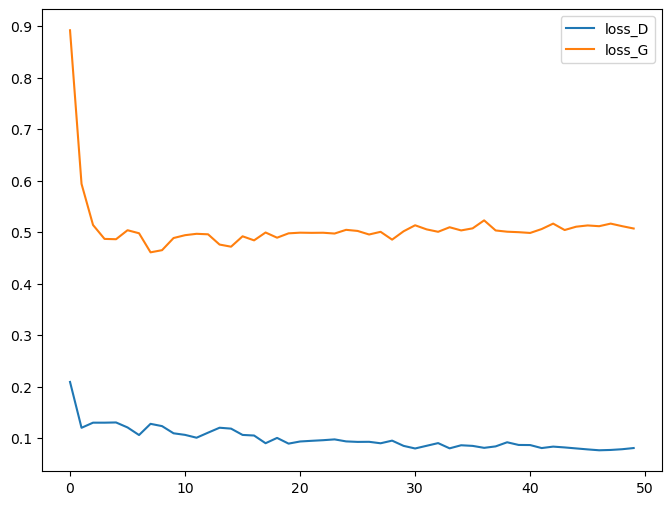

In [ ]:
num_epochs = 50
lr_D = 0.0002
lr_G = 0.0002
latent_dim = 1024
fixed_noise = torch.normal(0., 1., (10, latent_dim))

a = 0.
b = 1.
c = 1.

generator = VGGMnistGenerator(latent_dim=latent_dim, output_channels=1)
discriminator = VGGMnistDiscriminator(input_channels=1, alpha=0.2)
train_least_gan(D=discriminator, G=generator, device=device,
                lr_D=lr_D, lr_G=lr_G, a=a, b=b, c=c,
                num_epochs=num_epochs, latent_dim=latent_dim,
                dataloader=dataloader,
                fixed_noise=fixed_noise)

